# Exploratory Data Analysis (EDA)
## Music Prediction Dataset - Phase 1

**Dataset:** 732,988 clean songs with audio features, lyrics, and metadata

**Target Variables:**
1. Valence (mood: sad → happy)
2. Energy (intensity)
3. Danceability
4. Popularity

**Goals:**
- Understand data distributions
- Identify correlations
- Detect patterns by genre/year
- Plan feature engineering strategy

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [2]:
# Load cleaned dataset
data_path = Path('../dataset/processed/songs_ml_ready.csv')
print(f"Loading data from: {data_path}")

df = pd.read_csv(data_path)

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading data from: ../dataset/processed/songs_ml_ready.csv

✅ Dataset loaded successfully!
Shape: 732,988 rows × 20 columns


In [3]:
# First look at the data
df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,year,genre,popularity
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,['HELLYEAH'],0.415,0.605,7,-11.157,1,0.0575,0.001160,0.838000,0.4710,0.193,100.059,79500.0,"He said he came from Jamaica,\n he owned a cou...",2016,Rock,0
1,2ASl4wirkeYm3OWZxXKYuq,!!,NaN,Yxngxr1,0.788,0.648,7,-9.135,0,0.3150,0.900000,0.000000,0.1760,0.287,79.998,114000.0,"Fucked a bitch, now she running with my kids\n...",2019,Hip-Hop,28
2,4U7dlZjg1s9pjdppqZy0fm,!!De Repente!!,Un Palo Al Agua (20 Grandes Canciones),['Rosendo'],0.657,0.882,5,-6.340,1,0.0385,0.007400,0.000013,0.0474,0.939,123.588,198173.0,Continuamente se extraña la gente si no puede ...,2000,Rock,5
3,4v1IBp3Y3rpkWmWzIlkYju,!!De Repente!!,Fuera De Lugar,['Rosendo'],0.659,0.893,5,-8.531,1,0.0411,0.092200,0.000019,0.0534,0.951,123.600,199827.0,Continuamente se extraña la gente si no puede ...,1986,Rock,14
4,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,NaN,Dillinger Four,0.171,0.957,2,-5.749,1,0.1490,0.000029,0.000032,0.3300,0.349,175.317,197400.0,You like to stand on the other side\n Point an...,2002,Rock,7


In [4]:
# Column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732988 entries, 0 to 732987
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                732988 non-null  object 
 1   name              732986 non-null  object 
 2   album_name        284940 non-null  object 
 3   artists           732988 non-null  object 
 4   danceability      732988 non-null  float64
 5   energy            732988 non-null  float64
 6   key               732988 non-null  object 
 7   loudness          732988 non-null  float64
 8   mode              732988 non-null  object 
 9   speechiness       732988 non-null  float64
 10  acousticness      732988 non-null  float64
 11  instrumentalness  732988 non-null  float64
 12  liveness          732988 non-null  float64
 13  valence           732988 non-null  float64
 14  tempo             732988 non-null  float64
 15  duration_ms       732988 non-null  float64
 16  lyrics            73

## 2. Basic Statistics

In [5]:
# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,popularity
count,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000
mean,0.541,0.666,-7.776,0.084,0.268,0.092,0.226,0.484,122.709,236521.096,2007.885,17.699
std,0.172,0.241,3.832,0.092,0.310,0.225,0.201,0.251,29.461,93088.657,12.942,17.453
min,0.046,0.000,-46.383,0.022,0.000,0.000,0.007,0.000,30.946,15027.000,1900.000,0.000
25%,0.424,0.495,-9.719,0.035,0.007,0.000,0.100,0.278,99.827,185397.750,2003.000,0.000
50%,0.547,0.706,-6.959,0.049,0.116,0.000,0.141,0.473,121.625,223059.500,2011.000,14.000
75%,0.667,0.875,-5.054,0.090,0.490,0.014,0.295,0.685,140.632,268840.000,2017.000,30.000
max,0.991,1.000,0.000,0.966,0.996,0.998,1.000,1.000,246.130,4995315.000,2025.000,91.000


In [6]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
}).sort_values('Missing', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing'] > 0])

Missing Values Summary:
            Missing  Percentage
album_name   448048       61.13
lyrics            8        0.00
name              2        0.00


## 3. Target Variables Analysis
### Our 4 targets: Valence, Energy, Danceability, Popularity

In [7]:
# Define target variables
target_vars = ['valence', 'energy', 'danceability', 'popularity']

# Check completeness
print("Target Variables Completeness:")
for target in target_vars:
    complete = df[target].notna().sum()
    pct = (complete / len(df) * 100)
    print(f"{target:15s}: {complete:,} / {len(df):,} ({pct:.2f}%)")

Target Variables Completeness:
valence        : 732,988 / 732,988 (100.00%)
energy         : 732,988 / 732,988 (100.00%)
danceability   : 732,988 / 732,988 (100.00%)
popularity     : 732,988 / 732,988 (100.00%)


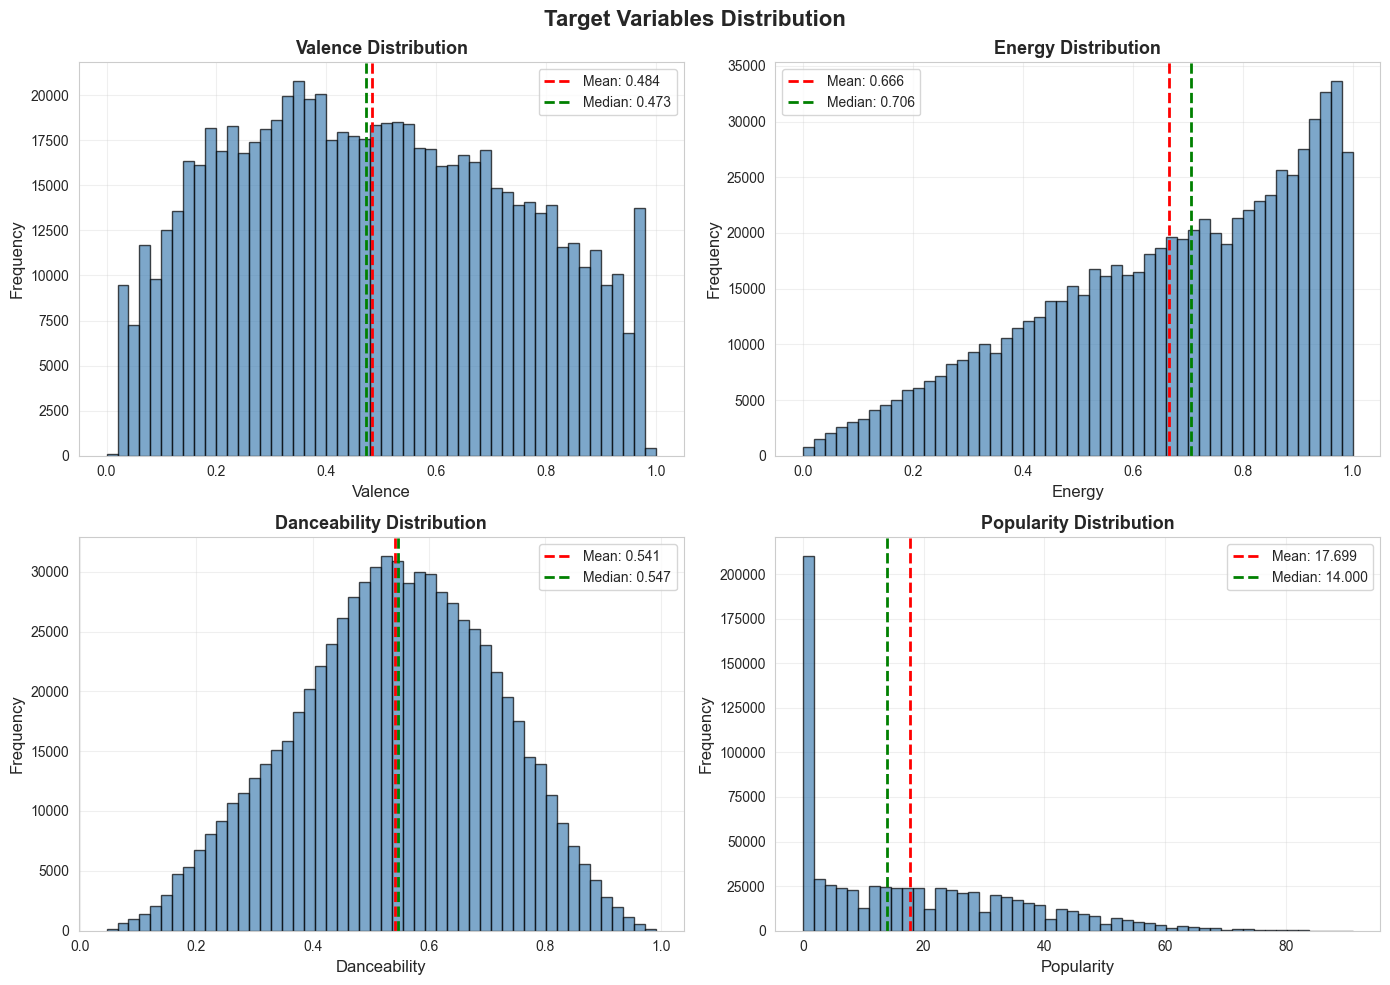


Target Variables Statistics:
          valence      energy  danceability  popularity
count  732988.000  732988.000    732988.000  732988.000
mean        0.484       0.666         0.541      17.699
std         0.251       0.241         0.172      17.453
min         0.000       0.000         0.046       0.000
25%         0.278       0.495         0.424       0.000
50%         0.473       0.706         0.547      14.000
75%         0.685       0.875         0.667      30.000
max         1.000       1.000         0.991      91.000


In [8]:
# Target variables distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variables Distribution', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Histogram
    ax.hist(df[target].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df[target].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[target].mean():.3f}')
    ax.axvline(df[target].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[target].median():.3f}')
    
    ax.set_xlabel(target.capitalize(), fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{target.capitalize()} Distribution', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("\nTarget Variables Statistics:")
print(df[target_vars].describe().round(3))

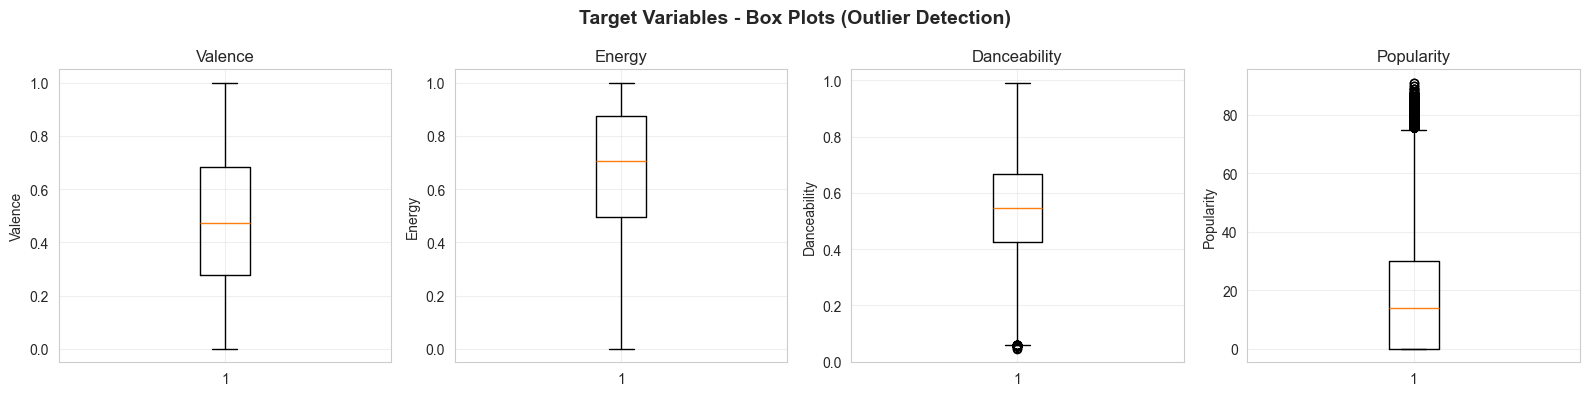

In [9]:
# Box plots for targets
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Target Variables - Box Plots (Outlier Detection)', fontsize=14, fontweight='bold')

for idx, target in enumerate(target_vars):
    axes[idx].boxplot(df[target].dropna(), vert=True)
    axes[idx].set_ylabel(target.capitalize())
    axes[idx].set_title(f'{target.capitalize()}')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Audio Features Analysis
### Features that will be used for prediction

In [10]:
# Define audio features
audio_features = [
    'acousticness', 'instrumentalness', 'liveness', 'speechiness',
    'loudness', 'tempo', 'duration_ms', 'key', 'mode'
]

print("Audio Features Summary:")
df[audio_features].describe().round(3)

Audio Features Summary:


,acousticness,instrumentalness,liveness,speechiness,loudness,tempo,duration_ms
count,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000,732988.000
mean,0.268,0.092,0.226,0.084,-7.776,122.709,236521.096
std,0.310,0.225,0.201,0.092,3.832,29.461,93088.657
min,0.000,0.000,0.007,0.022,-46.383,30.946,15027.000
25%,0.007,0.000,0.100,0.035,-9.719,99.827,185397.750
50%,0.116,0.000,0.141,0.049,-6.959,121.625,223059.500
75%,0.490,0.014,0.295,0.090,-5.054,140.632,268840.000
max,0.996,0.998,1.000,0.966,0.000,246.130,4995315.000


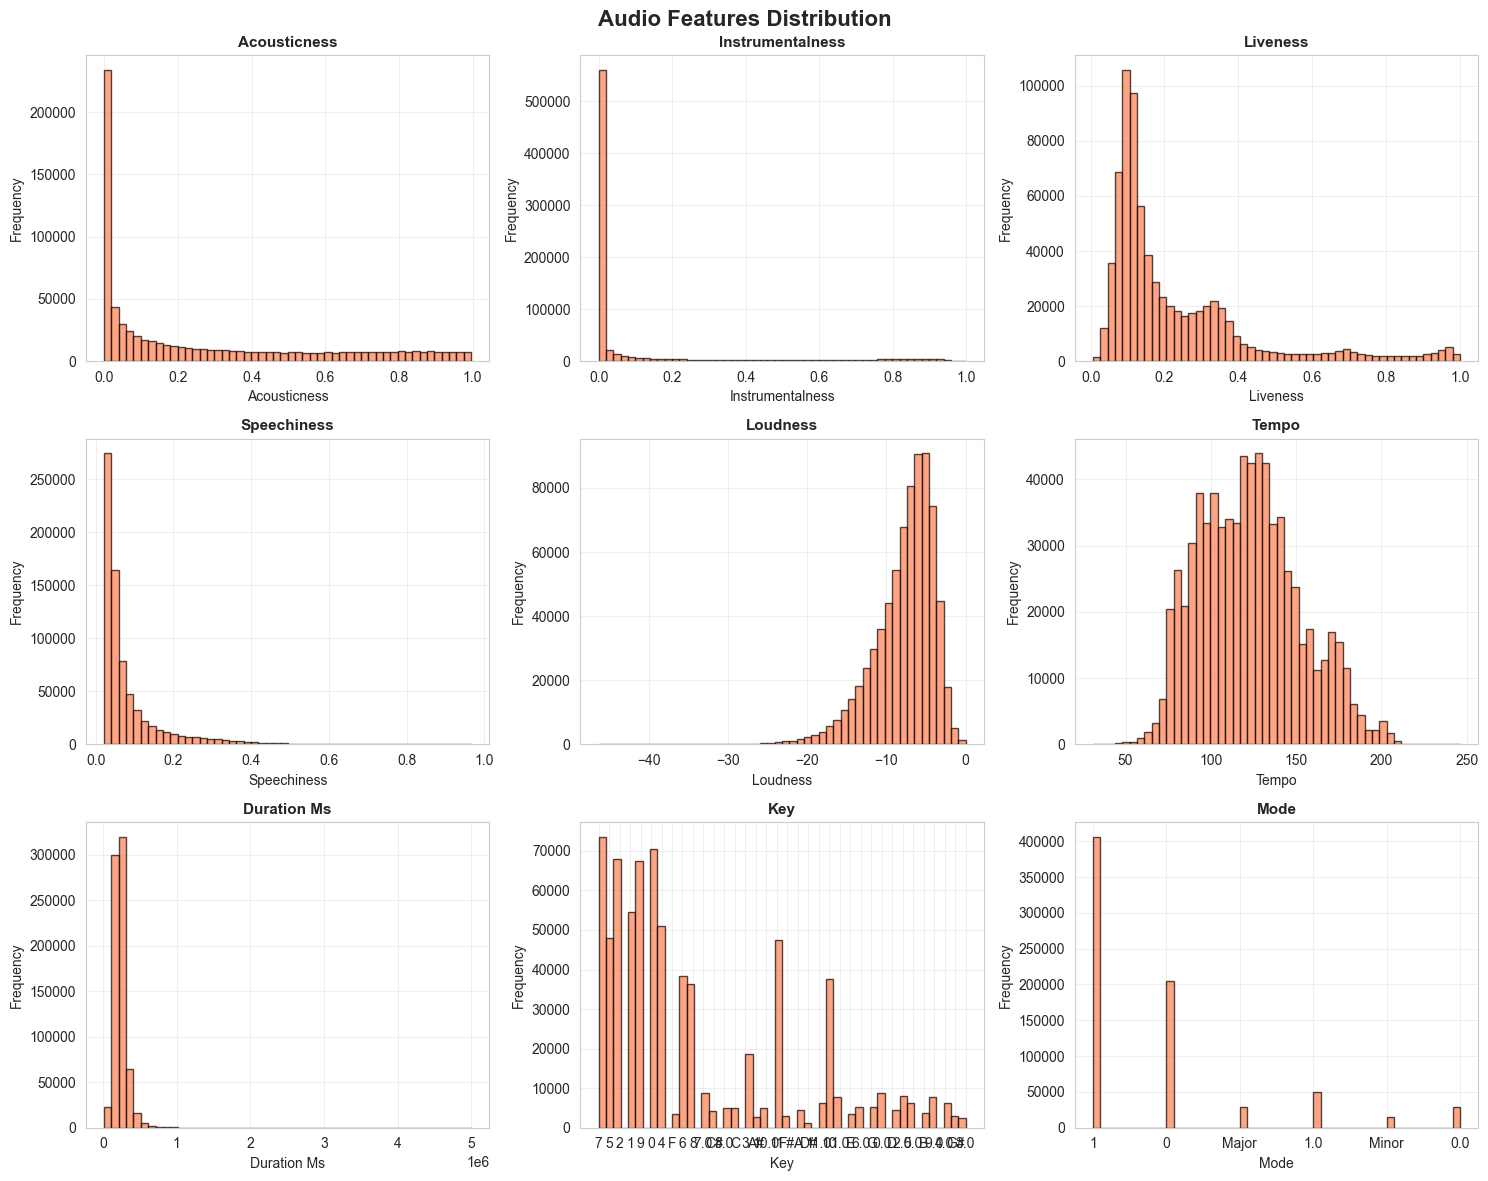

In [11]:
# Audio features distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Audio Features Distribution', fontsize=16, fontweight='bold')

for idx, feature in enumerate(audio_features):
    ax = axes[idx // 3, idx % 3]
    
    ax.hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Correlation Analysis
### How do features relate to our targets?

In [13]:
# Convert key and mode to numeric (they might be stored as strings)
# This ensures correlation analysis works correctly
df['key'] = pd.to_numeric(df['key'], errors='coerce')
df['mode'] = pd.to_numeric(df['mode'], errors='coerce')

print("Data types after conversion:")
print(f"key: {df['key'].dtype}")
print(f"mode: {df['mode'].dtype}")
print(f"\nSample key values: {df['key'].unique()[:15]}")
print(f"Sample mode values: {df['mode'].unique()}")

Data types after conversion:
key: float64
mode: float64

Sample key values: [ 7.  5.  2.  1.  9.  0.  4. nan  6.  8.  3. 10. 11.]
Sample mode values: [ 1.  0. nan]


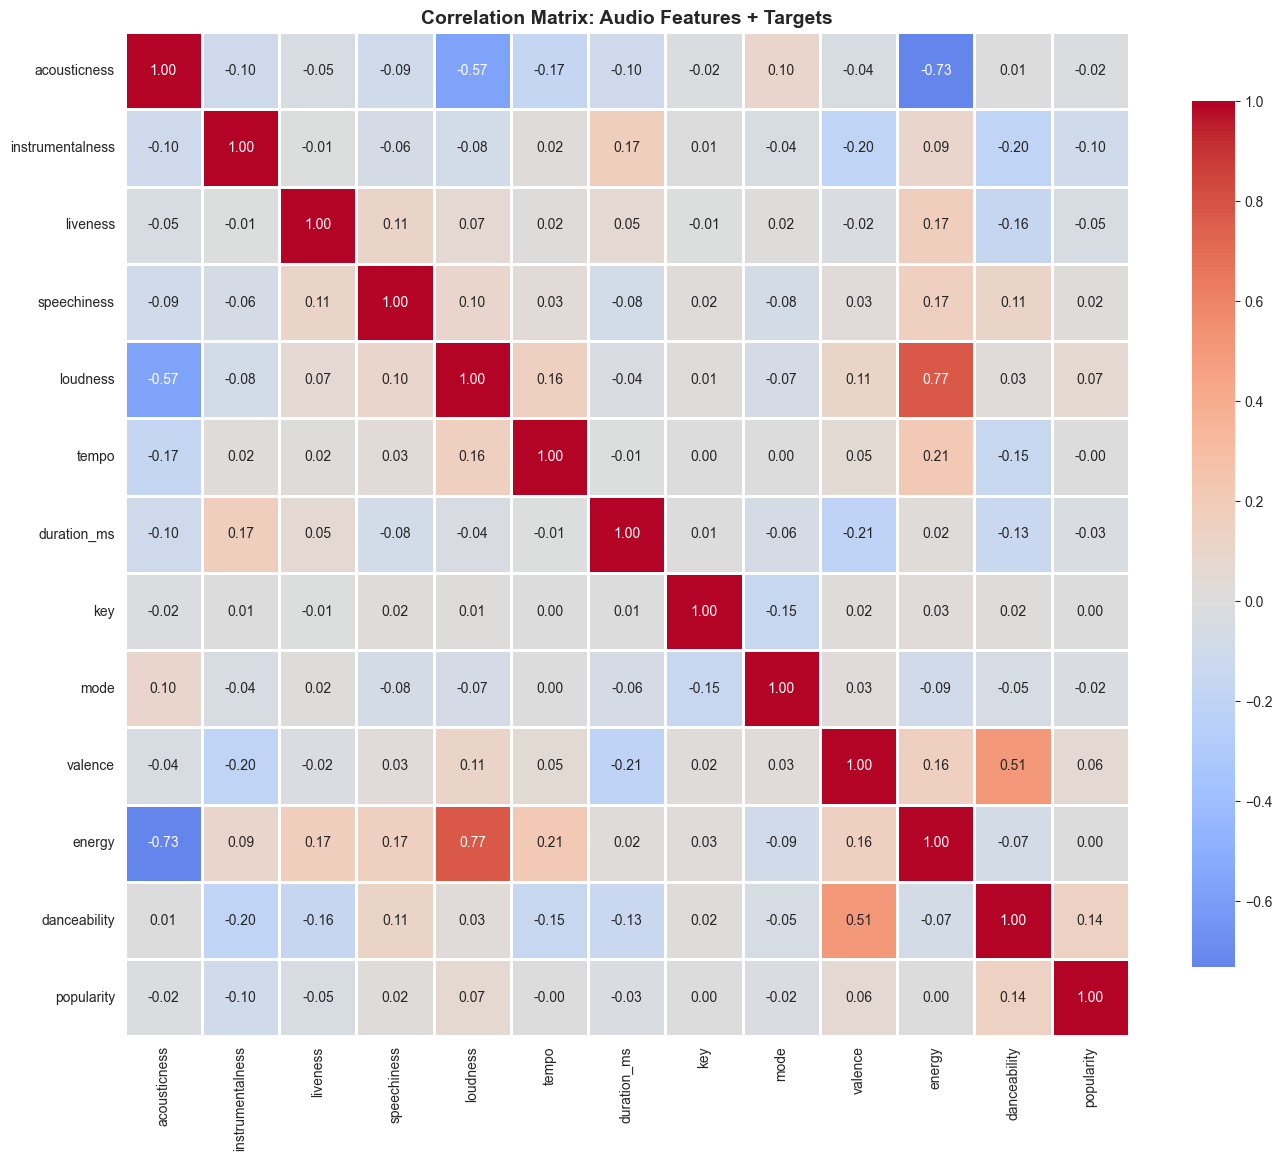

In [14]:
# Correlation matrix: All numeric features
correlation_cols = audio_features + target_vars
corr_matrix = df[correlation_cols].corr()

# Full correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Audio Features + Targets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

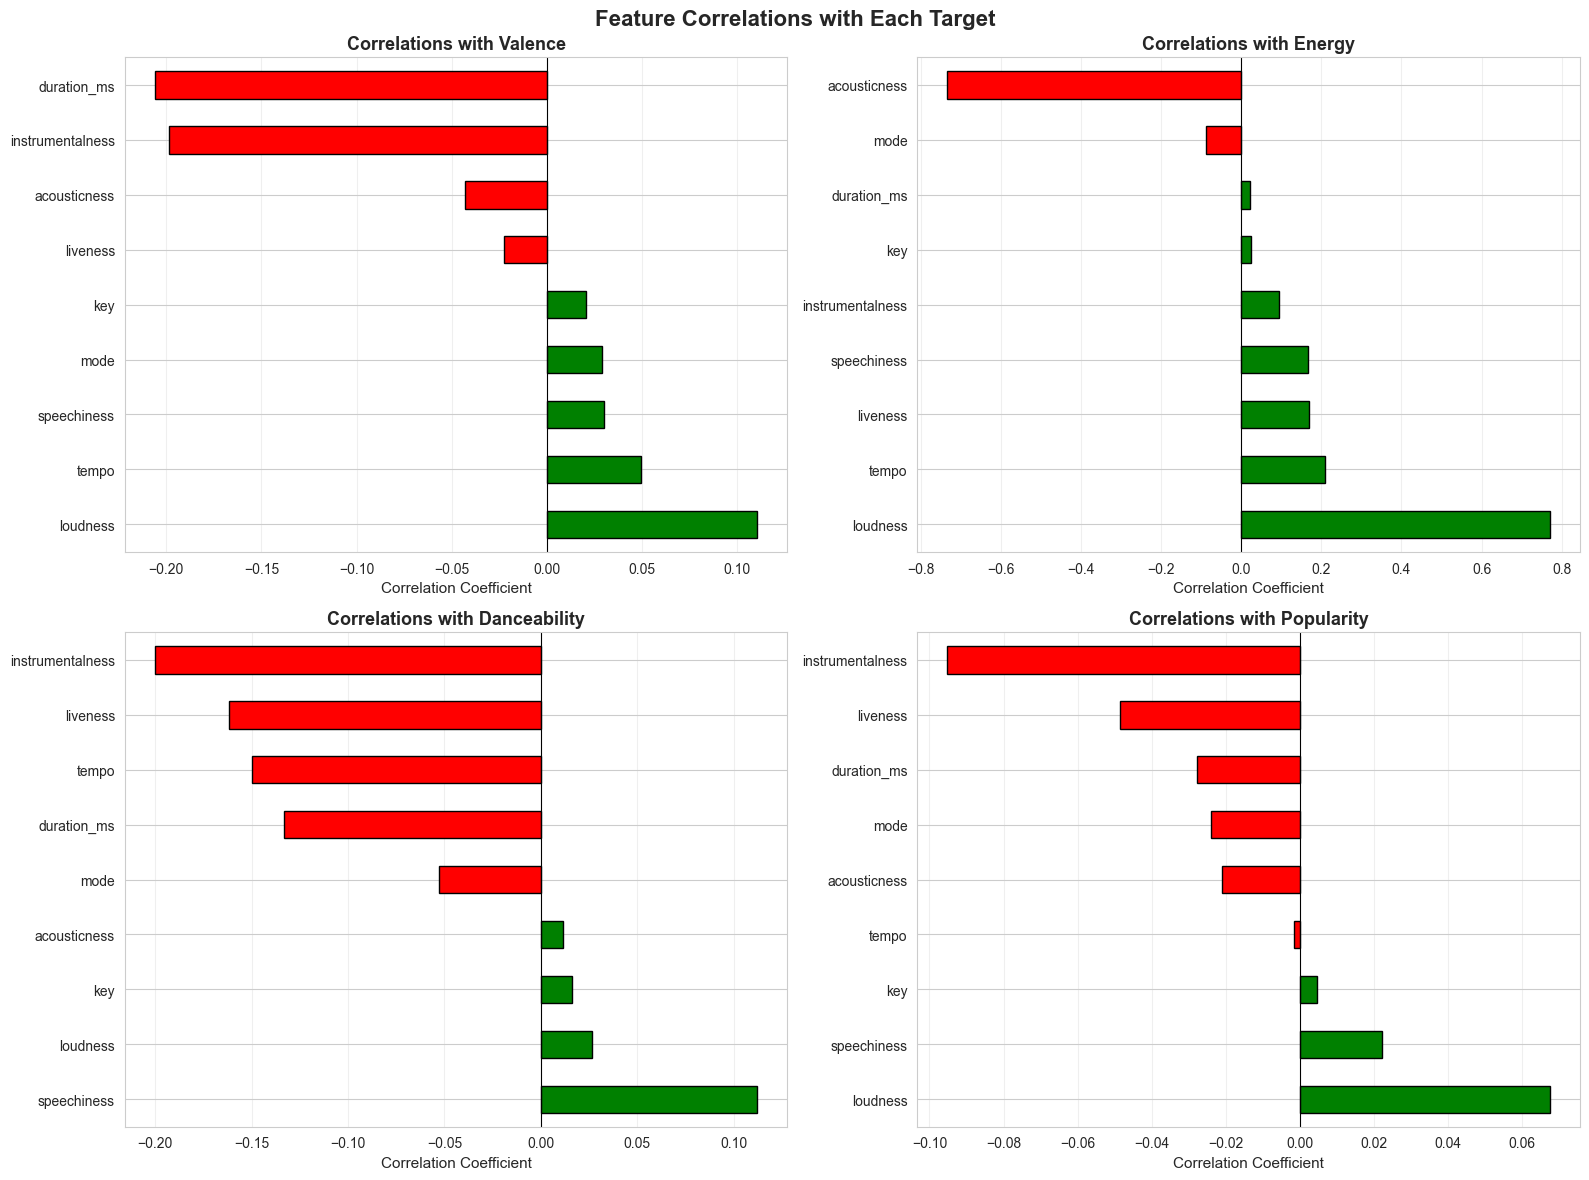


Top 5 Positive/Negative Correlations for Each Target:


VALENCE:
  Positive: {'loudness': 0.11054699725342695, 'tempo': 0.04963975702007805, 'speechiness': 0.029871902763492636}
  Negative: {'acousticness': -0.043219771644890444, 'instrumentalness': -0.19851018564382308, 'duration_ms': -0.20595570516171505}

VALENCE:
  Positive: {'loudness': 0.11054699725342695, 'tempo': 0.04963975702007805, 'speechiness': 0.029871902763492636}
  Negative: {'acousticness': -0.043219771644890444, 'instrumentalness': -0.19851018564382308, 'duration_ms': -0.20595570516171505}

ENERGY:
  Positive: {'loudness': 0.7705734826952793, 'tempo': 0.20944388370913067, 'liveness': 0.16890947239958737}
  Negative: {'duration_ms': 0.023247745580817422, 'mode': -0.08814754326978935, 'acousticness': -0.7331439713238747}

ENERGY:
  Positive: {'loudness': 0.7705734826952793, 'tempo': 0.20944388370913067, 'liveness': 0.16890947239958737}
  Negative: {'duration_ms': 0.023247745580817422, 'mode': -0.08814754326978935, 'acou

In [15]:
# Correlation with each target (separate analysis)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Correlations with Each Target', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Get correlations with this target
    target_corr = df[audio_features + [target]].corr()[target].drop(target).sort_values(ascending=False)
    
    # Bar plot
    colors = ['green' if x > 0 else 'red' for x in target_corr.values]
    target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    
    ax.set_xlabel('Correlation Coefficient', fontsize=11)
    ax.set_title(f'Correlations with {target.capitalize()}', fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print top correlations for each target
print("\nTop 5 Positive/Negative Correlations for Each Target:\n")
for target in target_vars:
    target_corr = df[audio_features + [target]].corr()[target].drop(target).sort_values(ascending=False)
    print(f"\n{target.upper()}:")
    print(f"  Positive: {target_corr.head(3).to_dict()}")
    print(f"  Negative: {target_corr.tail(3).to_dict()}")

## 6. Genre Analysis
### How do targets vary by genre?

Total unique genres: 10

Top 10 genres:
genre
Rock          224355
Pop           154006
Electronic     79086
Folk           74727
Hip-Hop        61316
Country        56655
R&B            28460
Jazz           21663
Classical      16527
Blues          16193
Name: count, dtype: int64


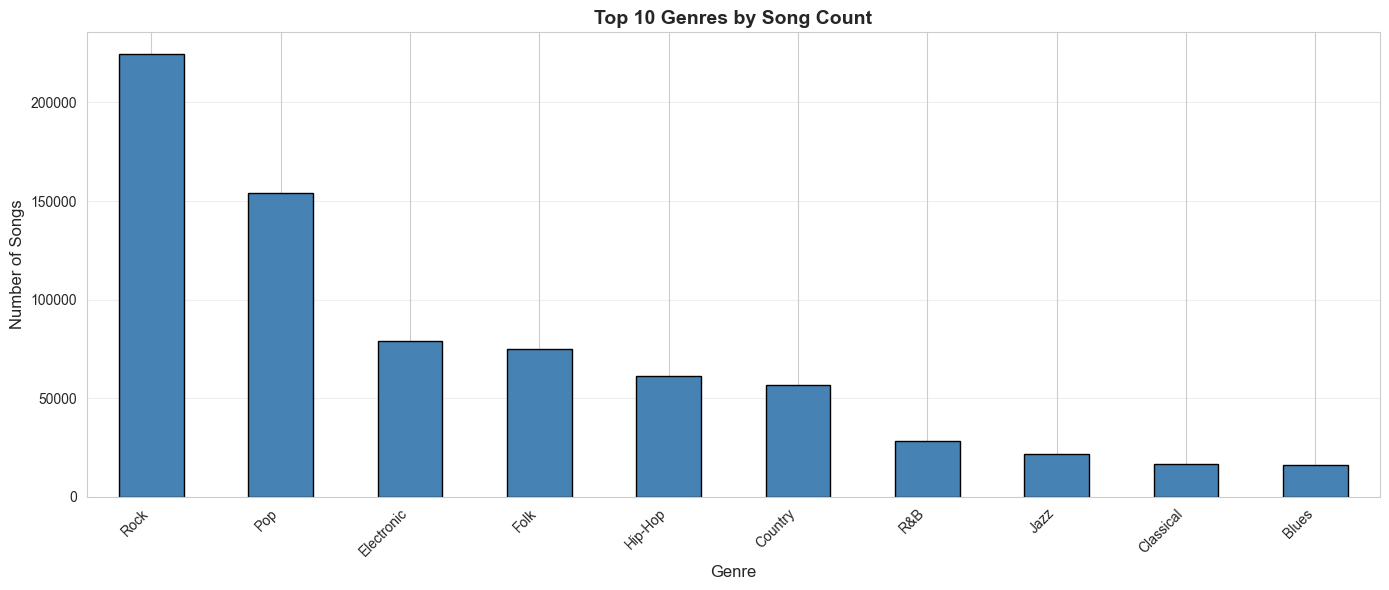

In [21]:
# Genre distribution
genre_counts = df['genre'].value_counts()

print(f"Total unique genres: {len(genre_counts)}")
print(f"\nTop 10 genres:")
print(genre_counts.head(10))

# Visualize top 10 genres
plt.figure(figsize=(14, 6))
genre_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Genres by Song Count', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

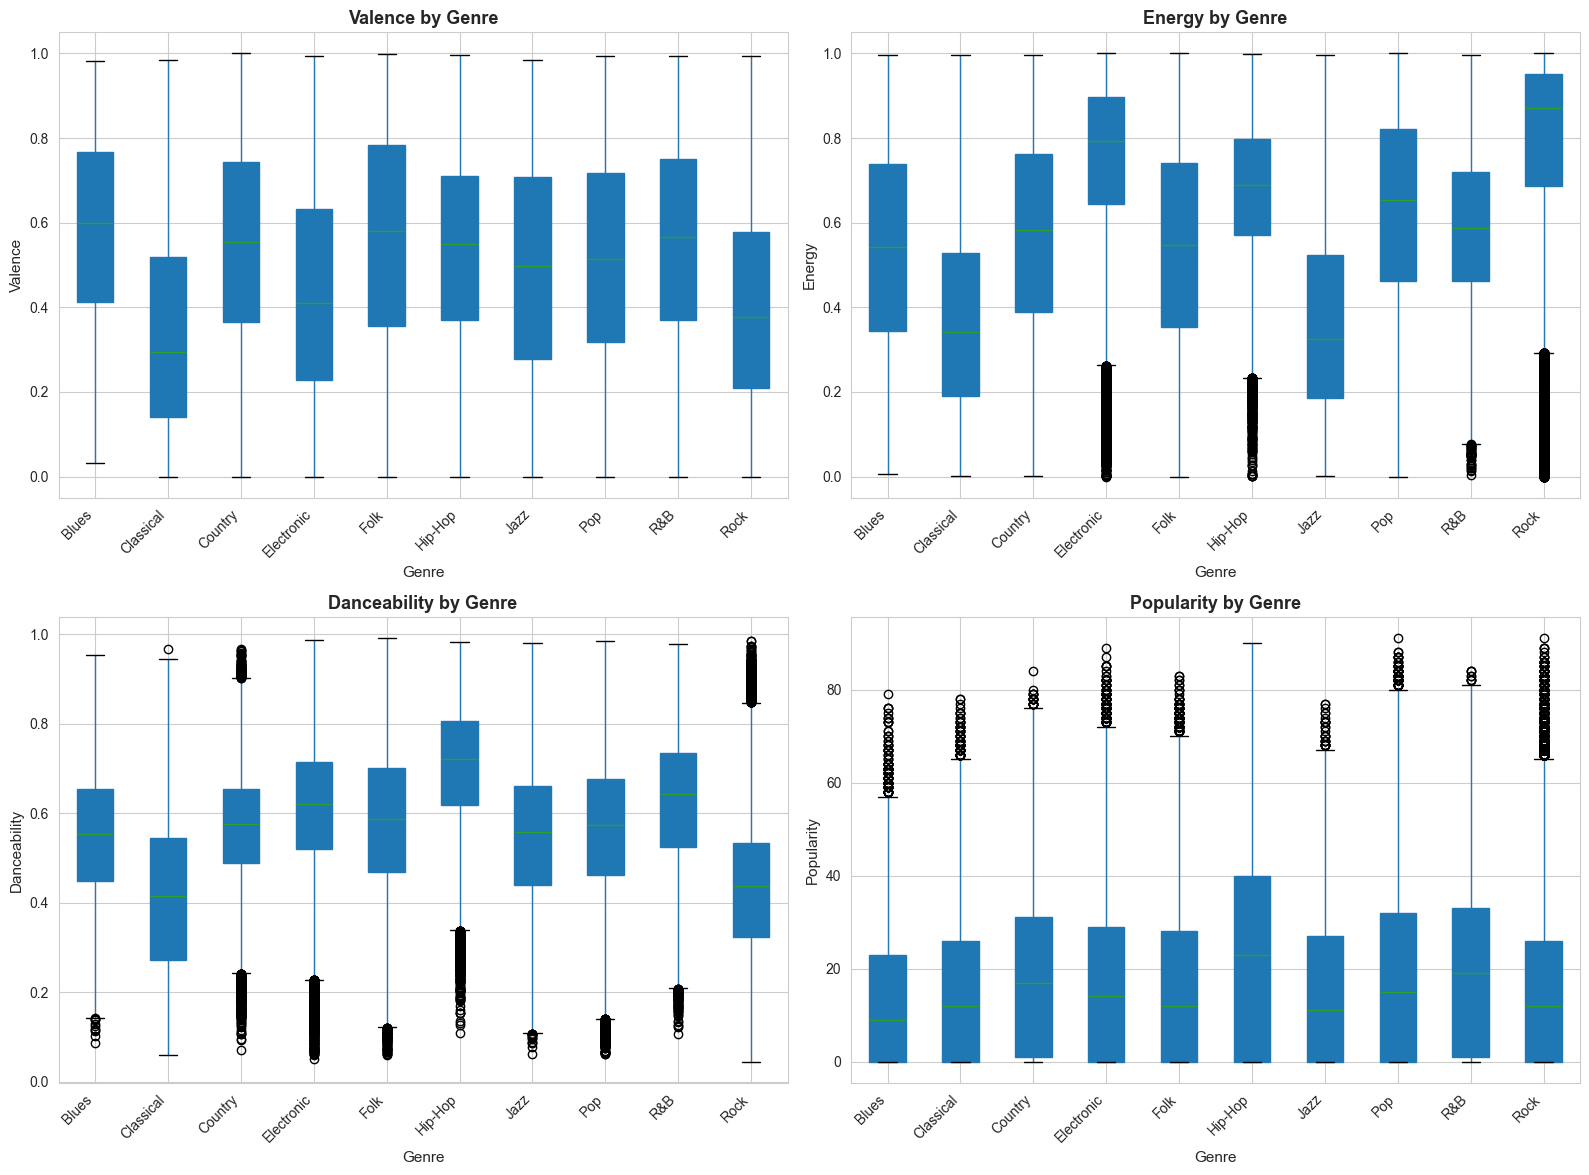

In [22]:
# Target variables by top genres
top_genres = genre_counts.head(10).index
df_top_genres = df[df['genre'].isin(top_genres)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Target Variables by Genre (Top 10 Genres)', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Box plot
    df_top_genres.boxplot(column=target, by='genre', ax=ax, patch_artist=True)
    ax.set_xlabel('Genre', fontsize=11)
    ax.set_ylabel(target.capitalize(), fontsize=11)
    ax.set_title(f'{target.capitalize()} by Genre', fontsize=13, fontweight='bold')
    ax.get_figure().suptitle('')  # Remove default title
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [23]:
# Mean target values by genre
genre_means = df.groupby('genre')[target_vars].mean().sort_values('valence', ascending=False)

print("\nTop 5 Happiest Genres (by valence):")
print(genre_means.head(5).round(3))

print("\nTop 5 Saddest Genres (by valence):")
print(genre_means.tail(5).round(3))


Top 5 Happiest Genres (by valence):
         valence  energy  danceability  popularity
genre                                             
Blues      0.585   0.539         0.550      13.412
Folk       0.566   0.545         0.582      16.286
R&B        0.558   0.587         0.625      20.378
Country    0.553   0.570         0.568      19.208
Hip-Hop    0.537   0.680         0.705      24.060

Top 5 Saddest Genres (by valence):
            valence  energy  danceability  popularity
genre                                                
Pop           0.519   0.630         0.565      19.083
Jazz          0.499   0.368         0.546      15.478
Electronic    0.440   0.750         0.611      16.838
Rock          0.408   0.793         0.432      15.738
Classical     0.348   0.375         0.416      15.656


## 7. Year Analysis
### How has music evolved over time?

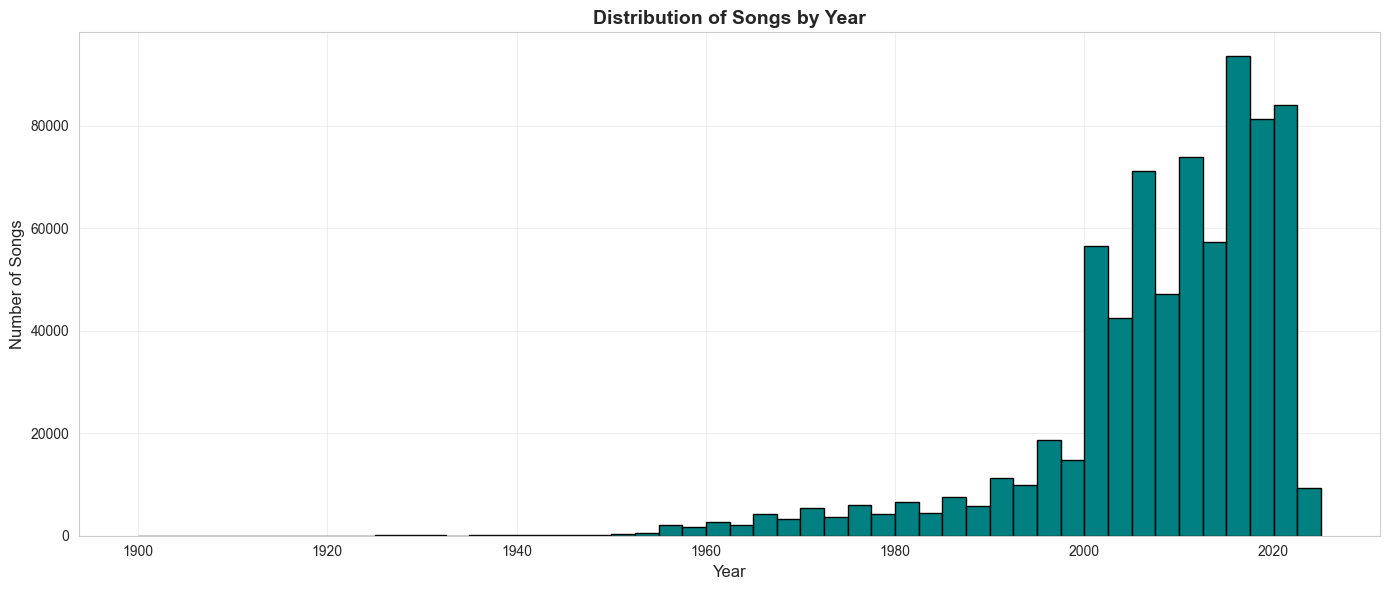

Year range: 1900 - 2025
Median year: 2011.0
Mean year: 2007.9


In [24]:
# Year distribution
plt.figure(figsize=(14, 6))
df['year'].hist(bins=50, edgecolor='black', color='teal')
plt.title('Distribution of Songs by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"Median year: {df['year'].median()}")
print(f"Mean year: {df['year'].mean():.1f}")

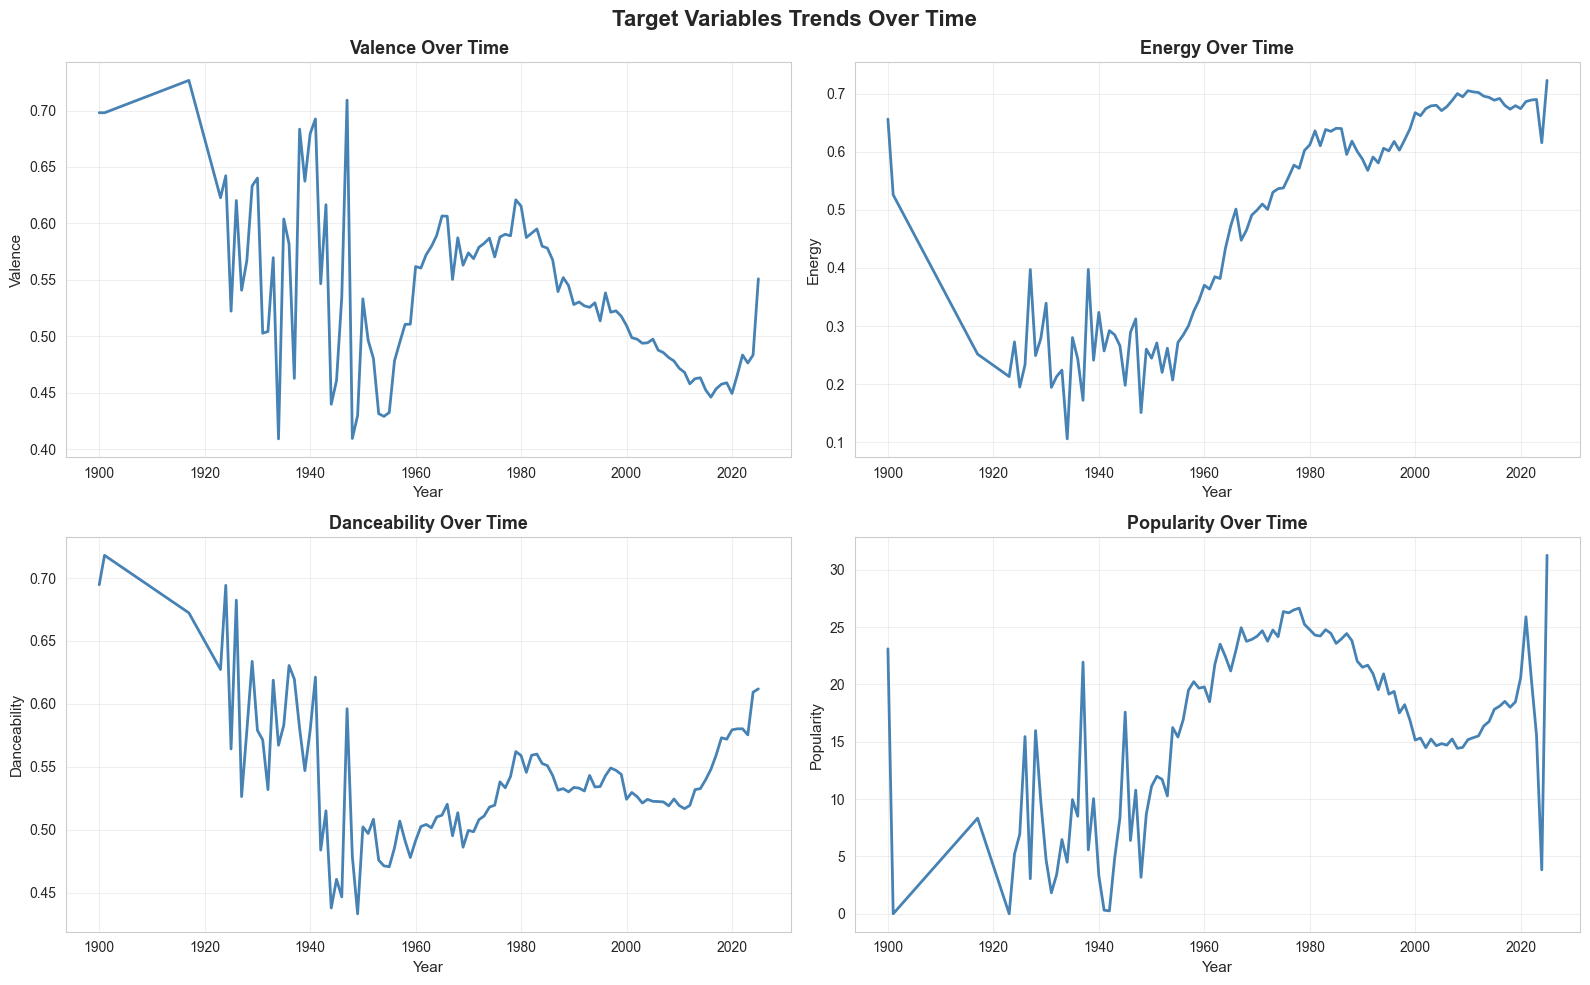

In [25]:
# Target trends over time
# Group by year and calculate means
year_trends = df.groupby('year')[target_vars].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Target Variables Trends Over Time', fontsize=16, fontweight='bold')

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    year_trends[target].plot(ax=ax, linewidth=2, color='steelblue')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel(target.capitalize(), fontsize=11)
    ax.set_title(f'{target.capitalize()} Over Time', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Lyrics Analysis
### Basic text statistics

In [26]:
# Lyrics availability
has_lyrics = df['lyrics'].notna() & (df['lyrics'].str.len() > 0)
print(f"Songs with lyrics: {has_lyrics.sum():,} ({has_lyrics.sum()/len(df)*100:.2f}%)")
print(f"Songs without lyrics: {(~has_lyrics).sum():,} ({(~has_lyrics).sum()/len(df)*100:.2f}%)")

Songs with lyrics: 732,980 (100.00%)
Songs without lyrics: 8 (0.00%)


In [31]:
# Basic lyrics statistics (on a sample to avoid memory issues)
sample_size = min(10000, has_lyrics.sum())
df_with_lyrics = df[has_lyrics].sample(n=sample_size, random_state=42)

# Calculate basic stats
df_with_lyrics['word_count'] = df_with_lyrics['lyrics'].str.split().str.len()
df_with_lyrics['char_count'] = df_with_lyrics['lyrics'].str.len()

print(f"\nLyrics Statistics (sample of {sample_size:,} songs):")
print(df_with_lyrics[['word_count', 'char_count']].describe().round(1))


Lyrics Statistics (sample of 10,000 songs):
       word_count  char_count
count     10000.0     10000.0
mean        259.1      1360.3
std         202.4      1047.2
min           1.0        12.0
25%         146.8       774.0
50%         218.0      1134.0
75%         310.0      1623.0
max        4240.0     21793.0


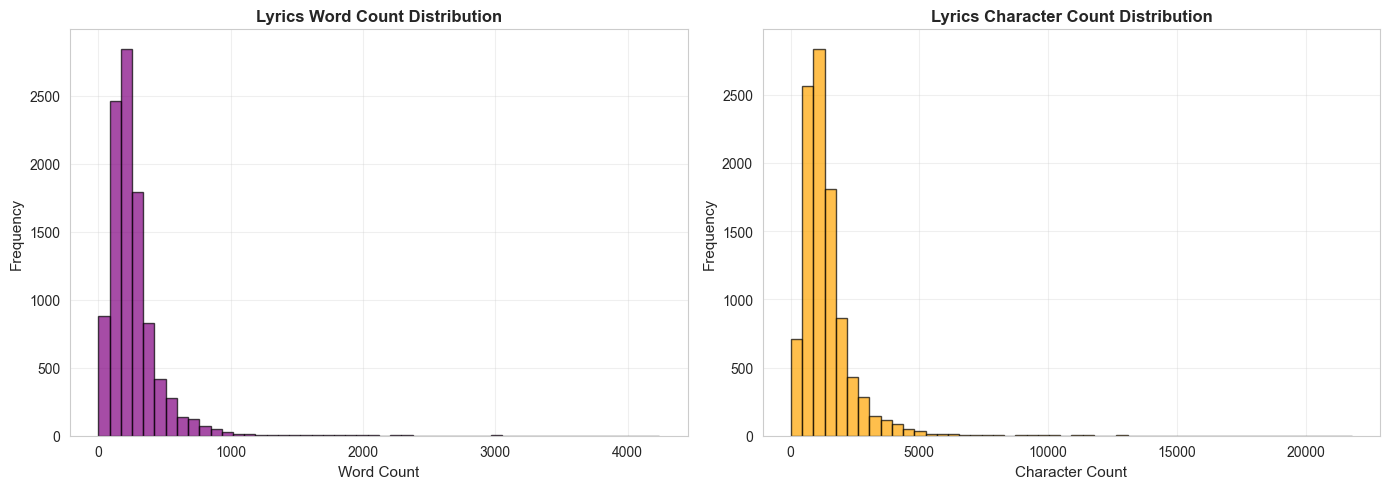

In [32]:
# Lyrics length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_with_lyrics['word_count'], bins=50, edgecolor='black', color='purple', alpha=0.7)
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Lyrics Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(df_with_lyrics['char_count'], bins=50, edgecolor='black', color='orange', alpha=0.7)
axes[1].set_xlabel('Character Count', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Lyrics Character Count Distribution', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Artist Analysis

Total unique artists: 108,096

Top 20 artists by song count:
artists
['Various Artists']       3148
Grateful Dead             1308
['Aretha Franklin']       1067
['Bob Dylan']              983
['Elvis Presley']          825
['Fleetwood Mac']          712
['Dolly Parton']           684
Elvis Presley              679
['Johnny Cash']            672
['Frank Sinatra']          614
Various Artists            562
['Emmylou Harris']         520
['The Fall']               514
['Barry Manilow']          507
Vybz Kartel                506
['Willie Nelson']          506
['The Rolling Stones']     484
Glee Cast                  473
['Udo Jürgens']            459
['Al Jarreau']             450
Name: count, dtype: int64


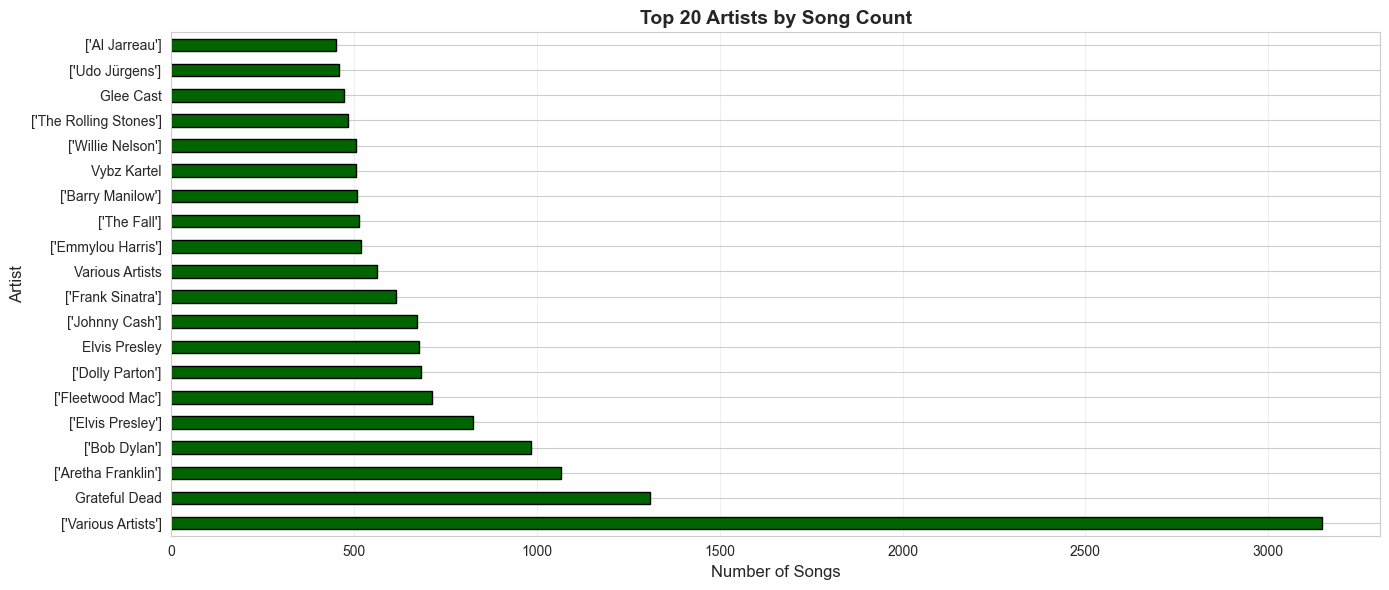


Artist Distribution:
  Artists with 1 song: 56,677
  Artists with 2-5 songs: 27,468
  Artists with 6-10 songs: 8,875
  Artists with >10 songs: 15,076


In [33]:
# Artist distribution
artist_counts = df['artists'].value_counts()

print(f"Total unique artists: {len(artist_counts):,}")
print(f"\nTop 20 artists by song count:")
print(artist_counts.head(20))

# Visualize
plt.figure(figsize=(14, 6))
artist_counts.head(20).plot(kind='barh', color='darkgreen', edgecolor='black')
plt.title('Top 20 Artists by Song Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Songs', fontsize=12)
plt.ylabel('Artist', fontsize=12)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Artist distribution stats
print(f"\nArtist Distribution:")
print(f"  Artists with 1 song: {(artist_counts == 1).sum():,}")
print(f"  Artists with 2-5 songs: {((artist_counts >= 2) & (artist_counts <= 5)).sum():,}")
print(f"  Artists with 6-10 songs: {((artist_counts >= 6) & (artist_counts <= 10)).sum():,}")
print(f"  Artists with >10 songs: {(artist_counts > 10).sum():,}")

## 10. Key Insights & Next Steps

In [34]:
print("="*80)
print("KEY INSIGHTS FROM EDA")
print("="*80)

print("\n📊 DATASET SUMMARY:")
print(f"  - Total songs: {len(df):,}")
print(f"  - Unique artists: {df['artists'].nunique():,}")
print(f"  - Unique genres: {df['genre'].nunique():,}")
print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
print(f"  - Songs with lyrics: {has_lyrics.sum():,} ({has_lyrics.sum()/len(df)*100:.1f}%)")

print("\n🎯 TARGET VARIABLES:")
for target in target_vars:
    print(f"  - {target.capitalize():15s}: Mean={df[target].mean():.3f}, Std={df[target].std():.3f}, Range=[{df[target].min():.3f}, {df[target].max():.3f}]")

print("\n🔗 TOP CORRELATIONS WITH TARGETS:")
for target in target_vars:
    target_corr = df[audio_features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
    top_feature = target_corr.index[0]
    top_value = target_corr.iloc[0]
    print(f"  - {target.capitalize():15s}: {top_feature} (r={top_value:.3f})")

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)
print("1. ✅ Create artist-aware train/val/test splits (prevent data leakage)")
print("2. ✅ Scale audio features (StandardScaler)")
print("3. ✅ Train baseline models (Mean, Linear, Ridge, XGBoost)")
print("4. ⏸️  Evaluate baseline performance")
print("5. ⏸️  Add text features if needed")
print("="*80)

KEY INSIGHTS FROM EDA

📊 DATASET SUMMARY:
  - Total songs: 732,988
  - Unique artists: 108,096
  - Unique genres: 10
  - Year range: 1900 - 2025
  - Songs with lyrics: 732,980 (100.0%)

🎯 TARGET VARIABLES:
  - Valence        : Mean=0.484, Std=0.251, Range=[0.000, 1.000]
  - Energy         : Mean=0.666, Std=0.241, Range=[0.000, 1.000]
  - Danceability   : Mean=0.541, Std=0.172, Range=[0.045, 0.991]
  - Popularity     : Mean=17.699, Std=17.453, Range=[0.000, 91.000]

🔗 TOP CORRELATIONS WITH TARGETS:
  - Valence        : duration_ms (r=0.206)
  - Valence        : duration_ms (r=0.206)
  - Energy         : loudness (r=0.771)
  - Energy         : loudness (r=0.771)
  - Danceability   : instrumentalness (r=0.200)
  - Danceability   : instrumentalness (r=0.200)
  - Popularity     : instrumentalness (r=0.095)

NEXT STEPS
1. ✅ Create artist-aware train/val/test splits (prevent data leakage)
2. ✅ Scale audio features (StandardScaler)
3. ✅ Train baseline models (Mean, Linear, Ridge, XGBoost)
4. ⏸

## 📝 Observations to Document

**Fill this in after running the notebook:**

1. **Target Distribution:**
   - Are targets balanced or skewed?
   - Any unusual patterns?

2. **Feature Correlations:**
   - Which features correlate strongly with each target?
   - Any multicollinearity issues?

3. **Genre Patterns:**
   - Do certain genres have distinct target values?
   - Genre imbalance?

4. **Temporal Trends:**
   - How have music characteristics changed over time?
   - Any era-specific patterns?

5. **Data Quality:**
   - Any remaining issues?
   - Features that need special handling?